In [ ]:
%pip install -r requirements.txt

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
import os

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: C:\Users\fredd\.cache\kagglehub\datasets\shauryasrivastava01\liver-patient-dataset\versions\1


In [3]:
# path = "Datasets/liver_patient_dataset.csv"
# df = pd.read_csv(path)

In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\fredd\.cache\kagglehub\datasets\shauryasrivastava01\liver-patient-dataset\versions\1


In [5]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [6]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [7]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

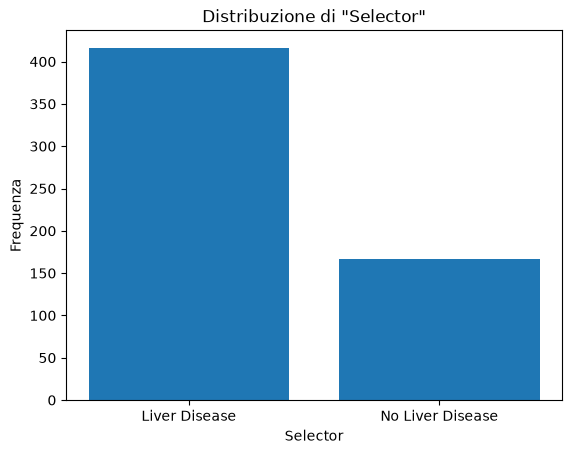

In [8]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [9]:
feature_names = df.columns.drop("Selector").tolist()

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = set(feature_names) - categorical_features

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'Alkphos', 'A/G Ratio', 'TB', 'Age', 'Sgpt', 'TP', 'DB', 'ALB', 'Sgot'}


In [10]:
df_encoded = df.copy()

df_encoded = pd.get_dummies(df_encoded, columns=["Gender"], dtype=int)
# Mapping esplicito: la classe positiva 1 indica la presenza di malattia epatica.
selector_mapping = {"Liver Disease": 1, "No Liver Disease": 0}
df_encoded["Selector"] = df_encoded["Selector"].map(selector_mapping)

if df_encoded["Selector"].isna().any():
    raise ValueError("Valori inattesi nella colonna Selector")

df_encoded["Selector"] = df_encoded["Selector"].astype("int8")
feature_names = df_encoded.columns.drop("Selector").tolist()
categorical_features_encoded = [
    col for col in feature_names if col.startswith("Gender_")
]
one_hot_groups = {"Gender": categorical_features_encoded}
integer_features = ["Age"]
continuous_features = [
    "TB", "DB", "Alkphos", "Sgpt", "Sgot",
    "TP", "ALB", "A/G Ratio"
]
feature_bounds = {
    "Age": (0, 120),
    **{col: (0, None) for col in continuous_features}
}

In [11]:
df_encoded

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector,Gender_Female,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,0,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,0,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
578,60,0.5,0.1,500,20,34,5.9,1.6,0.37,0,0,1
579,40,0.6,0.1,98,35,31,6.0,3.2,1.10,1,0,1
580,52,0.8,0.2,245,48,49,6.4,3.2,1.00,1,0,1
581,31,1.3,0.5,184,29,32,6.8,3.4,1.00,1,0,1


In [12]:
df_encoded["Selector"].dtype

dtype('int8')

In [13]:
df_encoded[categorical_features_encoded].dtypes

Gender_Female    int64
Gender_Male      int64
dtype: object

### addestriamo Il decisione Tree

In [14]:
X = df_encoded[feature_names]
y = df_encoded[target_name]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42,
    stratify=y_train_val
)  # circa 70% train, 15% validation, 15% test

In [15]:
df_encoded.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector,Gender_Female,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,0,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,0,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,0,1


In [16]:
X_train.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender_Female,Gender_Male
14,61,0.7,0.2,145,53,41,5.8,2.7,0.87,0,1
272,21,18.5,9.5,380,390,500,8.2,4.1,1.00,0,1
513,69,0.9,0.2,215,32,24,6.9,3.0,0.70,0,1
6,26,0.9,0.2,154,16,12,7.0,3.5,1.00,1,0
283,18,1.3,0.7,316,10,21,6.0,2.1,0.50,0,1


In [17]:
y_train.head()

14     1
272    1
513    1
6      1
283    0
Name: Selector, dtype: int8

In [18]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

Error in callback <function flush_figures at 0x000001C809F6C040> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[12 13]
 [16 47]]

Accuracy: 0.6704545454545454


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.48      0.45        25
           1       0.78      0.75      0.76        63

    accuracy                           0.67        88
   macro avg       0.61      0.61      0.61        88
weighted avg       0.68      0.67      0.68        88



### Miglioriamo l'albero

In [ ]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [ ]:
y_pred = prunedModel.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[ 4 21]
 [ 6 57]]

Accuracy: 0.6931818181818182


In [ ]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.16      0.23        25
           1       0.73      0.90      0.81        63

    accuracy                           0.69        88
   macro avg       0.57      0.53      0.52        88
weighted avg       0.64      0.69      0.64        88



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [ ]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00214988 0.00225225 0.002268   0.0022815  0.00235463
 0.0023868  0.00243193 0.00289442 0.00293475 0.0029484  0.00296324
 0.003276   0.003276   0.003276   0.003276   0.00342491 0.00350102
 0.0036855  0.0036855  0.0039312  0.0039312  0.00396396 0.004095
 0.00412289 0.0041276  0.004212   0.00425386 0.00432941 0.004368
 0.00448235 0.00453669 0.00486437 0.00501892 0.00515886 0.00659767
 0.00741488 0.0075618  0.00950242 0.01014648 0.0188357  0.04714385]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        validation_acc = clf.score(X_val, y_val)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "validation_accuracy": validation_acc
        })

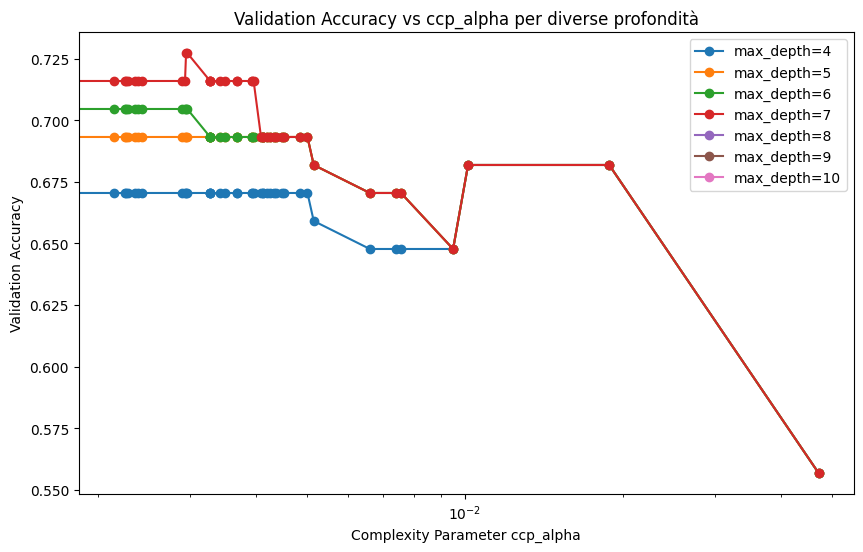

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["validation_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_result = max(results, key=lambda x: x["validation_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Validation accuracy:", best_result["validation_accuracy"])

Miglior max_depth: 7
Miglior ccp_alpha: 0.0029484029484029483
Train accuracy: 0.8058968058968059
Validation accuracy: 0.7272727272727273


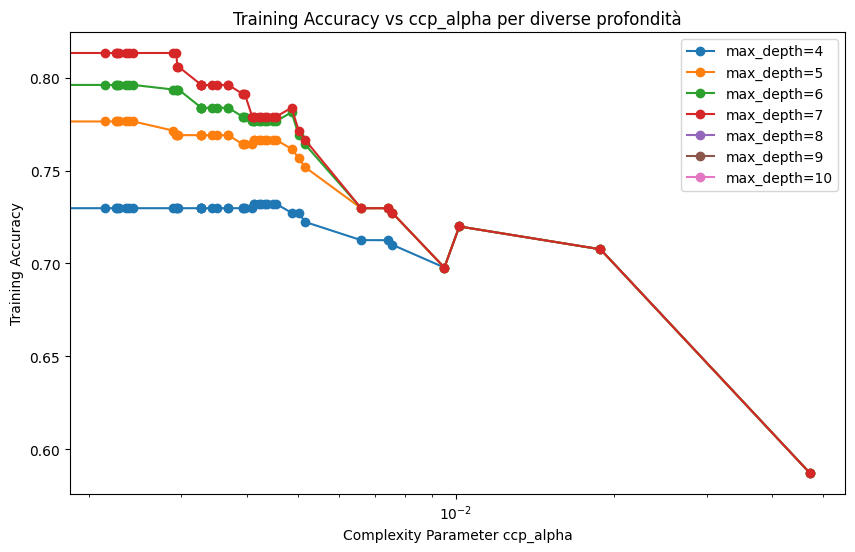

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.8058968058968059
Accuracy test: 0.6931818181818182


In [ ]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[19  6]
 [21 42]]

Accuracy: 0.6931818181818182


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.76      0.58        25
           1       0.88      0.67      0.76        63

    accuracy                           0.69        88
   macro avg       0.68      0.71      0.67        88
weighted avg       0.76      0.69      0.71        88



### diamo un occhiata con la balancedPrecision

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.76      0.58        25
           1       0.88      0.67      0.76        63

    accuracy                           0.69        88
   macro avg       0.68      0.71      0.67        88
weighted avg       0.76      0.69      0.71        88

Balanced accuracy: 0.7133333333333334
[[19  6]
 [21 42]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="macro_f1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1.5, 1: 1},
    {0: 2, 1: 1},
    {0: 2.5, 1: 1},
    {0: 3, 1: 1},
    {0: 4, 1: 1},
    {0: 4.5, 1: 1},
    {0: 5, 1: 1},
    {0: 7, 1: 1},
    {0: 9, 1: 1},
    {0: 10, 1: 1}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="macro_f1"
)


Migliore configurazione trovata:
max_depth                               7
ccp_alpha                        0.002935
class_weight               {0: 2.5, 1: 1}
weight_0                              2.5
weight_1                                1
train_accuracy                   0.805897
test_accuracy                    0.727273
train_balanced_accuracy          0.863793
test_balanced_accuracy           0.737143
precision_class_1                0.882353
recall_class_1                   0.714286
f1_class_1                       0.789474
macro_f1                         0.701188
weighted_f1                      0.739312
Name: 1488, dtype: object

Confusion matrix:
[[19  6]
 [18 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.51      0.76      0.61        25
           1       0.88      0.71      0.79        63

    accuracy                           0.73        88
   macro avg       0.70      0.74      0.70        88
weighted avg       

In [ ]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.47      0.76      0.58        25
           1       0.88      0.67      0.76        63

    accuracy                           0.69        88
   macro avg       0.68      0.71      0.67        88
weighted avg       0.76      0.69      0.71        88



### Facciamo un ensemble a majority

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, validation_index in splitter.split(X_train, y_train):
        # Ogni albero usa i due fold di training (circa il 66% dei dati).
        X_part = X_train.iloc[train_index]
        y_part = y_train.iloc[train_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="macro_f1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "accuracy": test_accuracy,
                    "balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1.5, 1: 1},
    {0: 2, 1: 1},
    {0: 2.5, 1: 1},
    {0: 3, 1: 1},
    {0: 4, 1: 1},
    {0: 5, 1: 1}
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_val,
    y_test=y_val,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="macro_f1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 3, 1: 1}, 'weight_0': 3, 'weight_1': 1, 'accuracy': 0.7159090909090909, 'balanced_accuracy': np.float64(0.7050793650793651), 'precision_class_1': 0.8518518518518519, 'recall_class_1': 0.7301587301587301, 'f1_class_1': 0.7863247863247863, 'macro_f1': 0.6812979863827322, 'weighted_f1': 0.726650468175892}

Confusion matrix:
[[17  8]
 [17 46]]

Classification report:
              precision    recall  f1-score   support

           0       0.50      0.68      0.58        25
           1       0.85      0.73      0.79        63

    accuracy                           0.72        88
   macro avg       0.68      0.71      0.68        88
weighted avg       0.75      0.72      0.73        88

Metrica usata per scegliere: macro_f1
Valore migliore: 0.6812979863827322


In [ ]:
results_df.sort_values(
    by="macro_f1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
949,7,0.002935,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
970,7,0.003276,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
963,7,0.002963,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
956,7,0.002948,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
942,7,0.002894,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
991,7,0.003276,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
984,7,0.003276,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
886,7,0.000000,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
893,7,0.002150,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665
900,7,0.002252,"{0: 3, 1: 1}",3.0,1,0.715909,0.705079,0.851852,0.730159,0.786325,0.681298,0.72665


In [ ]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.46      0.72      0.56        25
           1       0.86      0.67      0.75        63

    accuracy                           0.68        88
   macro avg       0.66      0.69      0.66        88
weighted avg       0.74      0.68      0.70        88



### gestione pesi per classe

In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def corrupt_rows_cat(X_train, col, frac=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    unique_values = X_train_corrupt[col].unique()

    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return X_train_corrupt

    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    if n_rows_to_corrupt == 0:
        return X_train_corrupt

    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        X_train_corrupt.at[idx, col] = rng.choice(pool_of_new_values)

    return X_train_corrupt


def corrupt_rows_cont(
    X_train, col, frac=0.1, noise_level=0.1, random_state=None,
    lower_bound=0, upper_bound=None
):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    X_train_corrupt[col] = X_train_corrupt[col].astype(float)

    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    if n_rows_to_corrupt == 0:
        return X_train_corrupt

    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    std_col = X_train_corrupt[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return X_train_corrupt

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        new_value = np.clip(current_value + noise, lower_bound, upper_bound)
        X_train_corrupt.at[idx, col] = new_value

    return X_train_corrupt


def one_hot_group_for_column(col):
    for group_name, group_cols in one_hot_groups.items():
        if col in group_cols:
            return group_name, group_cols
    return None, None


def corrupt_rows_one_hot(X_train, group_cols, frac=0.1, random_state=None):
    X_corrupt = X_train.copy()
    rng = np.random.default_rng(random_state)
    n_rows = int(frac * len(X_corrupt))
    indices = rng.choice(X_corrupt.index, size=n_rows, replace=False)
    for idx in indices:
        active = [col for col in group_cols if X_corrupt.at[idx, col] == 1]
        if len(active) != 1:
            raise ValueError(f"One-hot non valido alla riga {idx}")
        alternatives = [col for col in group_cols if col != active[0]]
        X_corrupt.loc[idx, group_cols] = 0
        X_corrupt.at[idx, rng.choice(alternatives)] = 1
    return X_corrupt


def feature_type(col):
    group_name, _ = one_hot_group_for_column(col)
    if group_name is not None:
        return "nominale"
    if col in integer_features:
        return "intera"
    if col in continuous_features:
        return "continua"
    raise ValueError(f"Feature senza tipo esplicito: {col}")


def corrupt_rows_age(X_train, frac=0.1, random_state=None):
    X_corrupt = X_train.copy()
    rng = np.random.default_rng(random_state)
    indices = rng.choice(
        X_corrupt.index, size=int(frac * len(X_corrupt)), replace=False
    )
    for idx in indices:
        current = int(X_corrupt.at[idx, "Age"])
        alternatives = [
            current + d for d in (-2, -1, 1, 2) if 0 <= current + d <= 120
        ]
        X_corrupt.at[idx, "Age"] = int(rng.choice(alternatives))
    return X_corrupt


def expand_feature_groups(features):
    expanded = []
    for feature in features:
        expanded.extend(one_hot_groups.get(feature, [feature]))
    return list(dict.fromkeys(expanded))


def corrupt_feature_columns(X_train, cols, frac, noise_level, random_state):
    X_corrupt = X_train.copy()
    processed_groups = set()
    for col_index, col in enumerate(cols):
        seed = random_state + col_index
        group_name, group_cols = one_hot_group_for_column(col)
        if group_name is not None:
            if group_name in processed_groups:
                continue
            X_corrupt = corrupt_rows_one_hot(
                X_corrupt, group_cols, frac=frac, random_state=seed
            )
            processed_groups.add(group_name)
        elif col == "Age":
            X_corrupt = corrupt_rows_age(X_corrupt, frac=frac, random_state=seed)
        else:
            lower, upper = feature_bounds[col]
            X_corrupt = corrupt_rows_cont(
                X_corrupt, col, frac, noise_level, seed, lower, upper
            )
    return X_corrupt



### mostro le variabili dalla più importante alla meno importante

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

def grouped_mutual_information(X, y, random_state=42):
    gender_cols = one_hot_groups["Gender"]
    if not (X[gender_cols].sum(axis=1) == 1).all():
        raise ValueError("Codifica one-hot non valida per Gender")
    grouped_data = {
        "Gender": np.argmax(X[gender_cols].to_numpy(), axis=1)
    }
    for col in X.columns:
        if col not in gender_cols:
            grouped_data[col] = X[col].to_numpy()
    grouped_X = pd.DataFrame(grouped_data, index=X.index)
    discrete_mask = [col == "Gender" for col in grouped_X.columns]
    mi = mutual_info_classif(
        grouped_X, y, discrete_features=discrete_mask, random_state=random_state
    )
    return pd.DataFrame({
        "variabile": grouped_X.columns, "importanza": mi
    }).sort_values("importanza", ascending=False)


def select_feature_group(X, y, feature_group, random_state=42):
    ranking = grouped_mutual_information(X, y, random_state)
    ordered = ranking["variabile"].tolist()
    middle = len(ordered) // 2
    selected = ordered[:middle] if feature_group == "migliori" else ordered[middle:]
    return expand_feature_groups(selected), ranking


# Stesso training split usato dai modelli principali.
importanza_variabili = grouped_mutual_information(X_train, y_train, 42)
print(importanza_variabili)

   variabile  importanza
5       Sgpt    0.081705
1        Age    0.068543
3         DB    0.063133
2         TB    0.055864
8        ALB    0.044244
4    Alkphos    0.036145
6       Sgot    0.028294
9  A/G Ratio    0.021321
0     Gender    0.013342
7         TP    0.000000


In [ ]:
feature_ordinate = importanza_variabili["variabile"].tolist()
n = len(feature_ordinate)
meta = n // 2

if n % 2 == 0:
    migliori = feature_ordinate[:meta]
    peggiori = feature_ordinate[meta:]
else:
    # la feature centrale appartiene a entrambe le liste
    migliori = feature_ordinate[:meta + 1]
    peggiori = feature_ordinate[meta:]

print("Migliori:", migliori)
print("Peggiori:", peggiori)

Migliori: ['Sgpt', 'Age', 'DB', 'TB', 'ALB']
Peggiori: ['Alkphos', 'Sgot', 'A/G Ratio', 'Gender', 'TP']


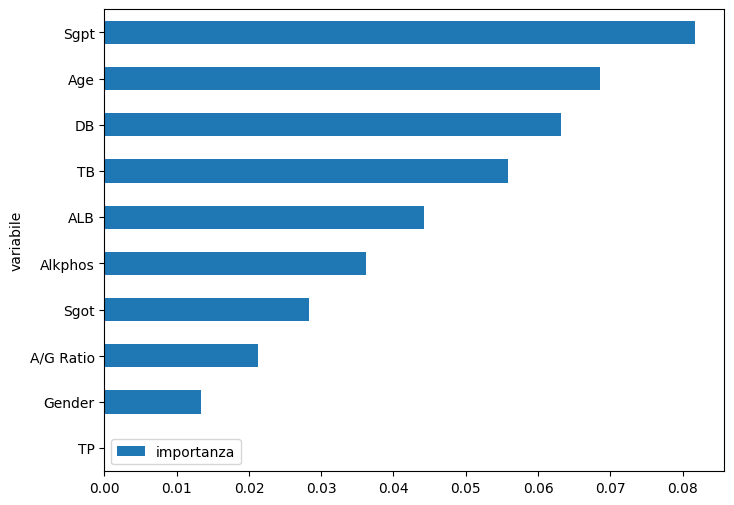

In [ ]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [ ]:
df_encoded.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector,Gender_Female,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,0,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,0,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,0,1


In [ ]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [ ]:
non_corrupted_data = [X_train, X_test, y_train, y_test]

In [ ]:
cols_noise_comparison = expand_feature_groups(migliori)
X_train_noisy = corrupt_feature_columns(
    X_train, cols_noise_comparison, frac=0.2, noise_level=0.1,
    random_state=42
)

In [ ]:
noise_training_results = search_best_ensemble_tree(
    X_train=X_train_noisy,
    y_train=y_train,
    X_test=X_val,
    y_test=y_val,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="macro_f1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.004864368500732139), 'class_weight': 'balanced', 'weight_0': 'b', 'weight_1': 'a', 'accuracy': 0.7613636363636364, 'balanced_accuracy': np.float64(0.7488888888888889), 'precision_class_1': 0.875, 'recall_class_1': 0.7777777777777778, 'f1_class_1': 0.8235294117647058, 'macro_f1': 0.7275541795665634, 'weighted_f1': 0.7689980298339432}

Confusion matrix:
[[18  7]
 [14 49]]

Classification report:
              precision    recall  f1-score   support

           0       0.56      0.72      0.63        25
           1       0.88      0.78      0.82        63

    accuracy                           0.76        88
   macro avg       0.72      0.75      0.73        88
weighted avg       0.79      0.76      0.77        88

Metrica usata per scegliere: macro_f1
Valore migliore: 0.7275541795665634


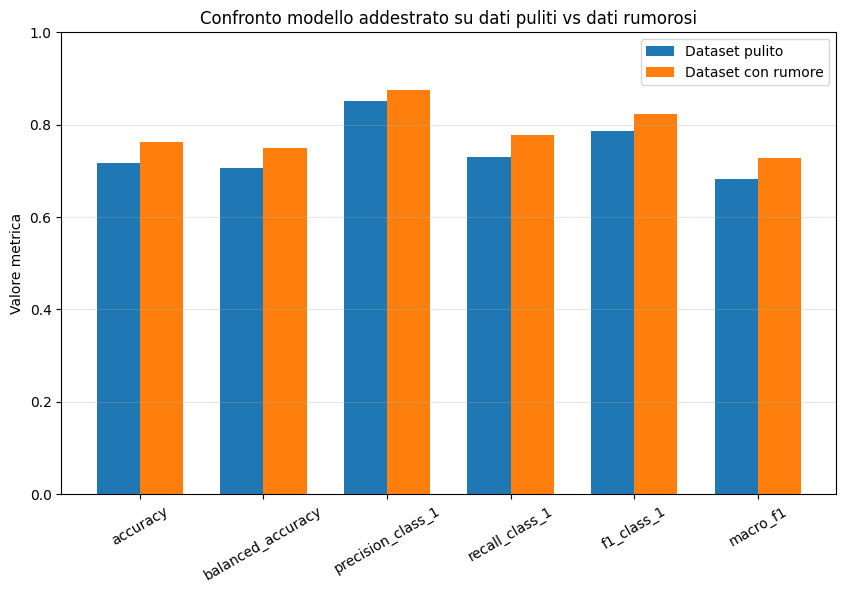

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1",
    "macro_f1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
df_encoded.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector,Gender_Female,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,0,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,0,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,0,1


In [ ]:

# X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
#     df=df_encoded,
#     target_col="Gender",
#     test_size=0.7,
#     random_state=42,
#     stratify=False
# )



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# La classe 0 (nessuna malattia) è minoritaria dopo il mapping esplicito.
tree_weights_to_try = [
    {0: 1, 1: 1},
    {0: 1.5, 1: 1},
    {0: 2, 1: 1},
    {0: 2.5, 1: 1},
    {0: 3, 1: 1},
    {0: 4, 1: 1},
    {0: 5, 1: 1}
]


def test_noise_progressivo(
    df,
    target_col,
    cols_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    scoring_metric="macro_f1",
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non devi sporcare la colonna target.")
    cols_to_corrupt = expand_feature_groups(cols_to_corrupt)

    # Split train/validation/test. Il test non partecipa alla selezione.
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    tipo_colonne = {col: feature_type(col) for col in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, tipo in tipo_colonne.items():
        print(f" - {col}: {tipo}")

    # ✔ rumore progressivo (include 0%)
    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        # reset train base
        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        X_train = corrupt_feature_columns(
            X_train, cols_to_corrupt, frac, noise_level, random_state
        )

        # ✔ training modello (ensemble tree search invariato)
        training_results = search_best_ensemble_tree(
            X_train=X_train,
            y_train=y_train,
            # La configurazione viene scelta sul validation set.
            X_test=X_val,
            y_test=y_val,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, validation_predictions = training_results

        # Il test set viene usato soltanto dopo la selezione dei parametri.
        best_predictions = predict_ensemble(best_models, X_test)
        accuracy = accuracy_score(y_test, best_predictions)
        balanced_accuracy = balanced_accuracy_score(y_test, best_predictions)
        precision = precision_score(y_test, best_predictions, pos_label=1, zero_division=0)
        recall = recall_score(y_test, best_predictions, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, best_predictions, pos_label=1, zero_division=0)
        macro_f1 = f1_score(
            y_test, best_predictions, average="macro", zero_division=0
        )

        # ✔ normalizzazione best_row
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row formato non valido")

        best_row_dict.update({
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "f1_class_1": f1,
            "macro_f1": macro_f1,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "tipo_colonne": str(tipo_colonne),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_finali.append(best_row_dict)

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions,
            "accuracy": accuracy
        }

    # ✔ dataframe finale
    risultati_df = pd.DataFrame(risultati_finali)

    # ✔ metriche disponibili
    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1",
        "macro_f1"
    ]

    metriche_presenti = [
        m for m in metriche_possibili if m in risultati_df.columns
    ]

    print(risultati_df)

    # ✔ grafico
    plt.figure(figsize=(10, 6))

    for m in metriche_presenti:

        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale di rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza ensemble alberi su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

In [ ]:
df_encoded.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector,Gender_Female,Gender_Male
0,65,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1,0
1,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,0,1
2,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,0,1
3,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0,1
4,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,0,1


Colonne da corrompere:
 - Alkphos: continua
 - Sgot: continua
 - A/G Ratio: continua
 - Gender_Female: nominale
 - Gender_Male: nominale
 - TP: continua

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1.5, 1: 1}, 'weight_0': 1.5, 'weight_1': 1, 'accuracy': 0.7317073170731707, 'balanced_accuracy': np.float64(0.7004310344827587), 'precision_class_1': 0.8333333333333334, 'recall_class_1': 0.7758620689655172, 'f1_class_1': 0.8035714285714286, 'macro_f1': 0.6902472527472527, 'weighted_f1': 0.7372353256499599}

Confusion matrix:
[[15  9]
 [13 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        24
           1       0.83      0.78      0.80        58

    accuracy                           0.73        82
   macro avg       0.68      0.70      0.69        82
weighted avg       0.75      0.73      0.74        82

Metrica usata per scegliere: macro_f1

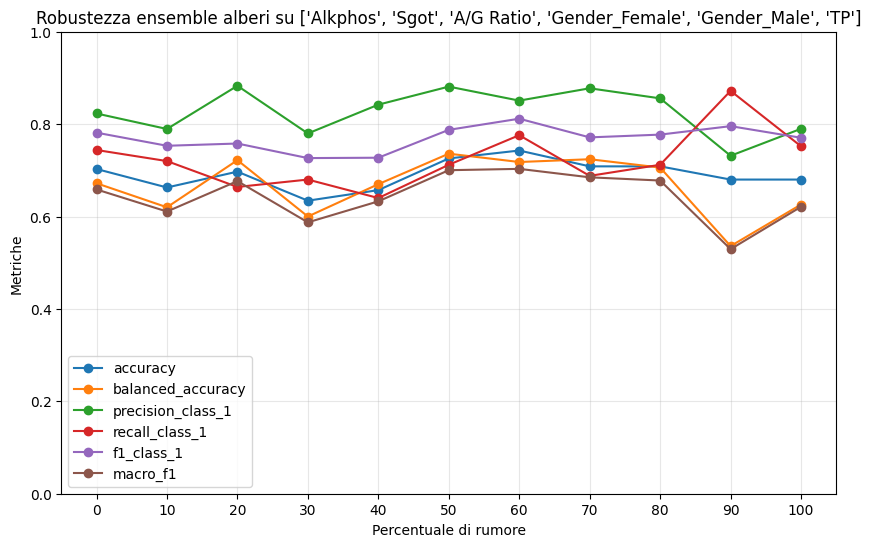

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    ccp_alphas=ccp_alphas,
    weights_to_try=tree_weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="macro_f1",
    stratify=True
)


Colonne da corrompere:
 - Sgpt: continua
 - Age: intera
 - DB: continua
 - TB: continua
 - ALB: continua

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1.5, 1: 1}, 'weight_0': 1.5, 'weight_1': 1, 'accuracy': 0.7317073170731707, 'balanced_accuracy': np.float64(0.7004310344827587), 'precision_class_1': 0.8333333333333334, 'recall_class_1': 0.7758620689655172, 'f1_class_1': 0.8035714285714286, 'macro_f1': 0.6902472527472527, 'weighted_f1': 0.7372353256499599}

Confusion matrix:
[[15  9]
 [13 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        24
           1       0.83      0.78      0.80        58

    accuracy                           0.73        82
   macro avg       0.68      0.70      0.69        82
weighted avg       0.75      0.73      0.74        82

Metrica usata per scegliere: macro_f1
Valore migliore: 0.6902472527472527

Rumore: 10

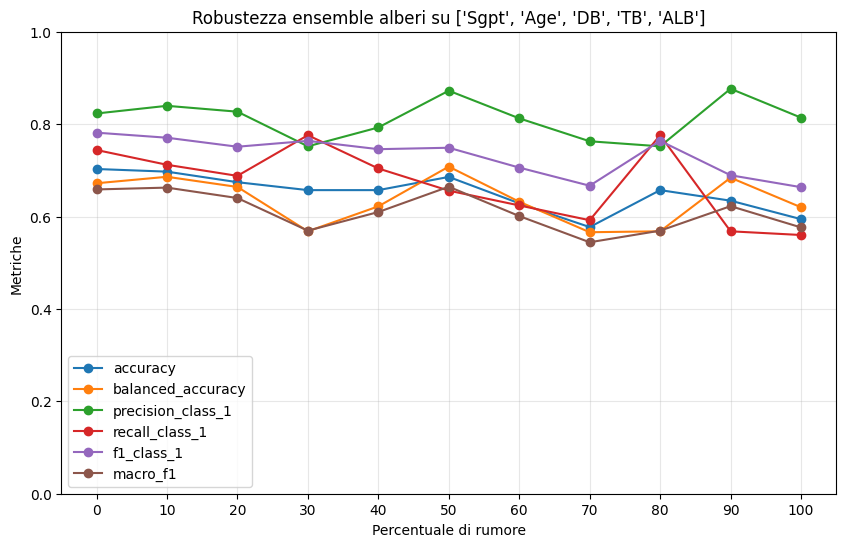

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    ccp_alphas=ccp_alphas,
    weights_to_try=tree_weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="macro_f1",
    stratify=True
)

Inizio rete neurale


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf


In [ ]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred = model.predict(X_test)

# conversione probabilità in classi
y_pred = (y_pred > 0.5).astype(int)



cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Confusion matrix:
 [[  4  46]
 [  3 122]]

Accuracy: 0.72


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_NN(input_dim, seed=None):
    tf.keras.backend.clear_session()

    if seed is not None:
        tf.keras.utils.set_random_seed(seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


def ensemble_predict_NN(models, X):
    preds = []

    for m in models:
        preds.append(m.predict(X, verbose=0))

    mean_pred = np.mean(preds, axis=0)

    return (mean_pred > 0.5).astype(int).flatten()


def test_noise_progressivo_NN(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10,
    feature_group=None,
    n_repeats=5,
    ensemble_size=3
):
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.utils.class_weight import compute_class_weight

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    if target_col in cols_to_corrupt:
        raise ValueError("Non puoi sporcare il target")

    X = df.drop(columns=[target_col])

    # Mapping già coerente: 1 = Liver Disease, 0 = No Liver Disease.
    y = df[target_col].astype(int)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    # I gruppi di feature vengono determinati usando soltanto il training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        cols_to_corrupt, feature_ranking = select_feature_group(
            X_train_full, y_train_full, feature_group, random_state
        )

    tipo_colonne = {col: feature_type(col) for col in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, tipo in tipo_colonne.items():
        print(f" - {col}: {tipo}")

    classes = np.sort(y_train_full.unique())
    balanced_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_full
    )
    class_weights = dict(zip(classes, balanced_weights))
    print("Class weights:", class_weights)

    percentuali_rumore = [
        0, 0.1, 0.2, 0.3, 0.4, 0.5,
        0.6, 0.7, 0.8, 0.9, 1.0
    ]
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1",
        "macro_f1"
    ]

    for frac in percentuali_rumore:
        percentuale = int(frac * 100)
        print(f"\nRumore: {percentuale}%")
        repeat_metrics = []
        repeat_details = []

        for repeat in range(n_repeats):
            X_train = X_train_full.copy()
            y_train = y_train_full.copy()

            X_train = corrupt_feature_columns(
                X_train, cols_to_corrupt, frac, noise_level,
                random_state + repeat * 1000
            )

            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            models = []
            model_seeds = []

            for model_index in range(ensemble_size):
                # Lo stesso repeat/model usa bootstrap e inizializzazione uguali
                # per tutti i livelli: cambia soltanto il rumore nei dati.
                seed_i = random_state + repeat * 1000 + model_index
                model_seeds.append(seed_i)
                rng_bootstrap = np.random.default_rng(seed_i)
                idx = rng_bootstrap.choice(
                    len(X_train_scaled),
                    len(X_train_scaled),
                    replace=True
                )

                X_boot = X_train_scaled[idx]
                y_boot = y_train.iloc[idx].to_numpy()
                model = build_model_NN(
                    input_dim=X_train_scaled.shape[1],
                    seed=seed_i
                )
                model.fit(
                    X_boot,
                    y_boot,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val_scaled, y_val),
                    class_weight=class_weights,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=5,
                        restore_best_weights=True
                    )],
                    verbose=0,
                    shuffle=True
                )
                models.append(model)

            y_pred = ensemble_predict_NN(models, X_test_scaled)
            metrics = {
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "precision_class_1": precision_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "recall_class_1": recall_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "f1_class_1": f1_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "macro_f1": f1_score(
                    y_test, y_pred, average="macro", zero_division=0
                )
            }
            repeat_metrics.append(metrics)
            repeat_details.append({
                "repeat": repeat,
                "model_seeds": model_seeds,
                "y_pred": y_pred,
                "metrics": metrics
            })

            # Non conserviamo i modelli Keras di tutti i repeat in memoria.
            del models

        result = {
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": percentuale,
            "n_repeats": n_repeats
        }
        for metric in metric_names:
            values = np.array([row[metric] for row in repeat_metrics])
            result[metric] = values.mean()
            result[f"{metric}_std"] = values.std(ddof=1) if n_repeats > 1 else 0.0

        risultati_finali.append(result)
        risultati_completi[percentuale] = {
            "X_train_clean": X_train_full,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train_full,
            "y_val": y_val,
            "y_test": y_test,
            "class_weights": class_weights,
            "repeats": repeat_details
        }

    risultati_df = pd.DataFrame(risultati_finali)

    plt.figure(figsize=(10, 6))
    for metric in metric_names:
        plt.errorbar(
            risultati_df["percentuale_rumore"],
            risultati_df[metric],
            yerr=risultati_df[f"{metric}_std"],
            marker="o",
            capsize=3,
            label=metric
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche (media ± deviazione standard)")
    plt.title(f"Robustezza NN ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)
    return risultati_df, risultati_completi


Colonne da corrompere:
 - Sgpt: continua
 - TP: continua
 - Gender_Female: nominale
 - Gender_Male: nominale
 - ALB: continua
 - A/G Ratio: continua
Class weights: {np.int64(0): np.float64(1.7526881720430108), np.int64(1): np.float64(0.6995708154506438)}

Rumore: 0%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 10%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 20%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 30%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 40%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 50%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 60%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 70%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 80%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 90%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 100%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

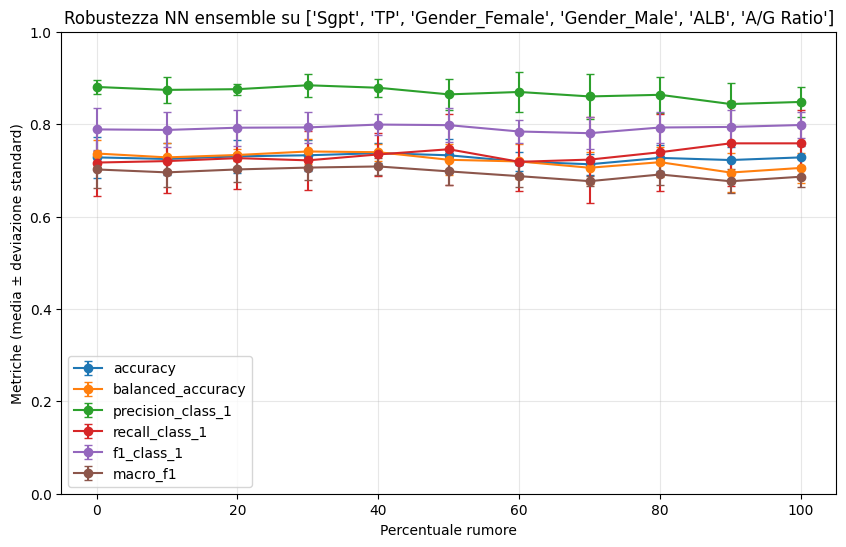

                                   colonne_sporcate  frac_rumore  \
0   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.0   
1   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.1   
2   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.2   
3   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.3   
4   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.4   
5   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.5   
6   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.6   
7   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.7   
8   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.8   
9   Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          0.9   
10  Sgpt,TP,Gender_Female,Gender_Male,ALB,A/G Ratio          1.0   

    percentuale_rumore  n_repeats  accuracy  accuracy_std  balanced_accuracy  \
0                    0          5  0.728000      0.045103             0.7364   
1                   10 

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    n_repeats=5,
    stratify=True,
)

Colonne da corrompere:
 - Age: intera
 - Sgot: continua
 - Alkphos: continua
 - DB: continua
 - TB: continua
Class weights: {np.int64(0): np.float64(1.7526881720430108), np.int64(1): np.float64(0.6995708154506438)}

Rumore: 0%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 10%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 20%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 30%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 40%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 50%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 60%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 70%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 80%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 90%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Rumore: 100%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

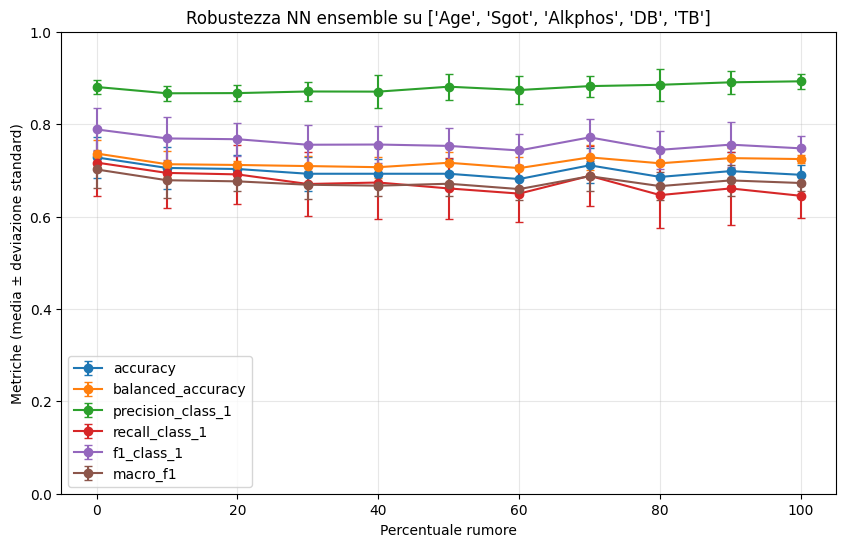

          colonne_sporcate  frac_rumore  percentuale_rumore  n_repeats  \
0   Age,Sgot,Alkphos,DB,TB          0.0                   0          5   
1   Age,Sgot,Alkphos,DB,TB          0.1                  10          5   
2   Age,Sgot,Alkphos,DB,TB          0.2                  20          5   
3   Age,Sgot,Alkphos,DB,TB          0.3                  30          5   
4   Age,Sgot,Alkphos,DB,TB          0.4                  40          5   
5   Age,Sgot,Alkphos,DB,TB          0.5                  50          5   
6   Age,Sgot,Alkphos,DB,TB          0.6                  60          5   
7   Age,Sgot,Alkphos,DB,TB          0.7                  70          5   
8   Age,Sgot,Alkphos,DB,TB          0.8                  80          5   
9   Age,Sgot,Alkphos,DB,TB          0.9                  90          5   
10  Age,Sgot,Alkphos,DB,TB          1.0                 100          5   

    accuracy  accuracy_std  balanced_accuracy  balanced_accuracy_std  \
0   0.728000      0.045103             

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    n_repeats=5,
    stratify=True,
)

Inizio svg

In [ ]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Creazione del modello SVM
model = SVC(
    kernel="rbf",        
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

# Addestramento
model.fit(X_train, y_train)

# Predizioni
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

Confusion matrix:
 [[46  4]
 [60 65]]

Accuracy: 0.6342857142857142


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_SVM():
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )
    return model


def ensemble_predict_SVM(models, X):

    preds = []

    for m in models:
        preds.append(m.predict(X))

    preds = np.array(preds)

    # Majority voting
    y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

    return y_pred




def test_noise_progressivo_SVM(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.1,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    stratify=False,
    feature_group=None,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    # SPLIT (allineato a NN: train_val/test, poi train_full/val)
    X = df.drop(columns=[target_col])
    # Il target è già codificato correttamente come 0/1.
    y = df[target_col].astype(int)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        cols_to_corrupt, feature_ranking = select_feature_group(
            X_train_full, y_train_full, feature_group, random_state
        )

    tipo_colonne = {col: feature_type(col) for col in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, tipo in tipo_colonne.items():
        print(f" - {col}: {tipo}")

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        X_train = corrupt_feature_columns(
            X_train, cols_to_corrupt, frac, noise_level, random_state
        )

        # Scaling stimato esclusivamente sul training del livello corrente.
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        models = []

        # ENSEMBLE CON BOOTSTRAP (FIX come NN)
        for i in range(3):


            # quesra riga non va bene, non ha un seed
            #idx = np.random.choice(len(X_train), len(X_train), replace=True)
            #fix:
            seed_i = random_state + i
            rng = np.random.default_rng(seed_i)

            idx = rng.choice(
                len(X_train_scaled),
                len(X_train_scaled),
                replace=True
            )

            X_boot = X_train_scaled[idx]
            y_boot = y_train.iloc[idx].to_numpy()

            model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced"
            )

            model.fit(X_boot, y_boot)

            models.append(model)

        # PREDIZIONE ENSEMBLE (majority vote coerente)
        preds = []

        for m in models:
            preds.append(m.predict(X_test_scaled))

        preds = np.array(preds)

        y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

        # METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(
            y_test, y_pred, average="macro", zero_division=0
        )

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "macro_f1": macro_f1,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "scaler": scaler,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    # GRAFICO IDENTICO NN
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1",
        "macro_f1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza SVM ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - Sgpt: continua
 - TP: continua
 - Gender_Female: nominale
 - Gender_Male: nominale
 - ALB: continua
 - A/G Ratio: continua

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


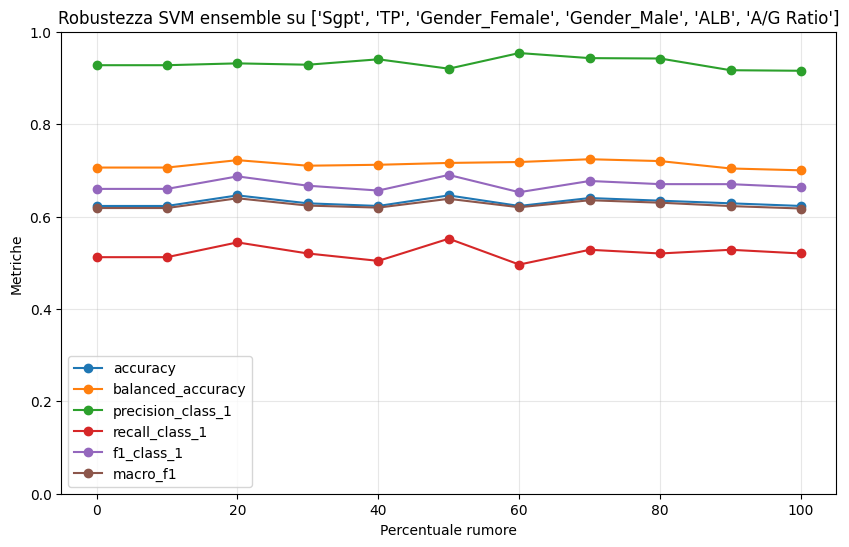

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.622857    0.659794           0.927536           0.512   
1   0.622857    0.659794           0.927536           0.512   
2   0.645714    0.686869           0.931507           0.544   
3   0.628571    0.666667           0.928571           0.520   
4   0.622857    0.656250           0.940299           0.504   
5   0.645714    0.690000           0.920000           0.552   
6   0.622857    0.652632           0.953846           0.496   
7   0.640000    0.676923           0.942857           0.528   
8   0.634286    0.670103           0.942029           0.520   
9   0.628571    0.670051           0.916667           0.528   
10  0.622857    0.663265           0.915493           0.520   

    balanced_accuracy  macro_f1  \
0               0.706  0.618358   
1               0.706  0.618358   
2               0.722  0.639487   
3               0.710  0.623656   
4               0.712  0.619264   
5               0.716  0.638333  

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    stratify=True,
)

Colonne da corrompere:
 - Age: intera
 - Sgot: continua
 - Alkphos: continua
 - DB: continua
 - TB: continua

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


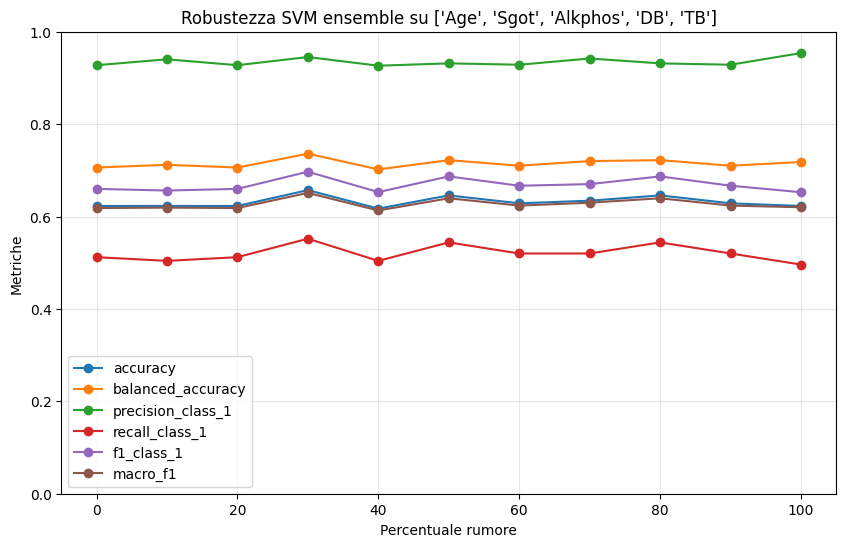

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.622857    0.659794           0.927536           0.512   
1   0.622857    0.656250           0.940299           0.504   
2   0.622857    0.659794           0.927536           0.512   
3   0.657143    0.696970           0.945205           0.552   
4   0.617143    0.652850           0.926471           0.504   
5   0.645714    0.686869           0.931507           0.544   
6   0.628571    0.666667           0.928571           0.520   
7   0.634286    0.670103           0.942029           0.520   
8   0.645714    0.686869           0.931507           0.544   
9   0.628571    0.666667           0.928571           0.520   
10  0.622857    0.652632           0.953846           0.496   

    balanced_accuracy  macro_f1        colonne_sporcate  frac_rumore  \
0               0.706  0.618358  Age,Sgot,Alkphos,DB,TB          0.0   
1               0.712  0.619264  Age,Sgot,Alkphos,DB,TB          0.1   
2               0.706  0.61

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    stratify=True,
)

   variabile  importanza
1        Age    0.095804
6       Sgot    0.055838
4    Alkphos    0.049570
3         DB    0.038744
2         TB    0.038151
5       Sgpt    0.026230
7         TP    0.007131
0     Gender    0.001745
8        ALB    0.000000
9  A/G Ratio    0.000000


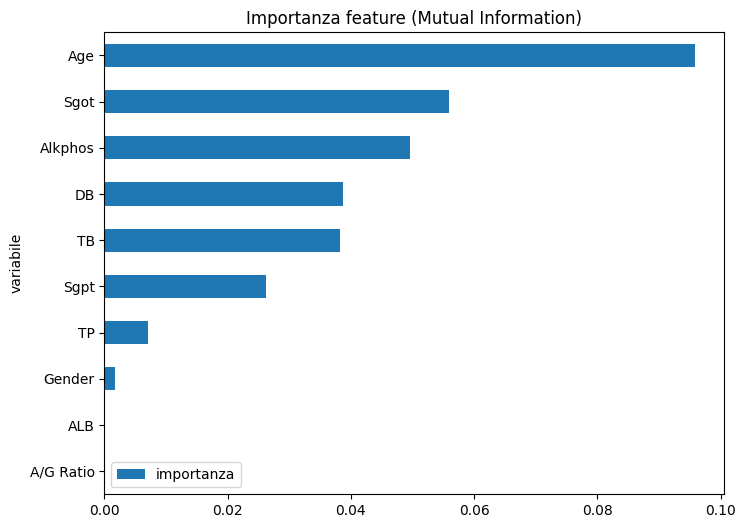

Migliori:  ['Age', 'Sgot', 'Alkphos', 'DB', 'TB']
Peggiori: ['Sgpt', 'TP', 'Gender', 'ALB', 'A/G Ratio']


In [ ]:
# Importanza delle feature (Mutual Information) calcolata DOPO lo split,
# usando esclusivamente il training set (stesso schema di split usato
# dalle funzioni di test: train_val/test, poi train_full/val).

X_mi = df_encoded.drop(columns=[target_name])
y_mi = df_encoded[target_name].astype(int)

X_mi_train_val, X_mi_test, y_mi_train_val, y_mi_test = train_test_split(
    X_mi, y_mi,
    test_size=0.3,
    random_state=42,
    stratify=y_mi
)

X_mi_train_full, X_mi_val, y_mi_train_full, y_mi_val = train_test_split(
    X_mi_train_val, y_mi_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_mi_train_val
)

importanza_variabili_post_split = grouped_mutual_information(
    X_mi_train_full, y_mi_train_full, random_state=42
)

print(importanza_variabili_post_split)

importanza_variabili_post_split.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.title("Importanza feature (Mutual Information)")
plt.show()

# Feature migliori/peggiori con la stessa logica usata sopra (cella "migliori"/"peggiori"),
# ma applicata al ranking calcolato dopo lo split.
feature_ordinate_post_split = importanza_variabili_post_split["variabile"].tolist()
n_post_split = len(feature_ordinate_post_split)
meta_post_split = n_post_split // 2

if n_post_split % 2 == 0:
    migliori_post_split = feature_ordinate_post_split[:meta_post_split]
    peggiori_post_split = feature_ordinate_post_split[meta_post_split:]
else:
    # la feature centrale appartiene a entrambe le liste
    migliori_post_split = feature_ordinate_post_split[:meta_post_split + 1]
    peggiori_post_split = feature_ordinate_post_split[meta_post_split:]

print("Migliori: ", migliori_post_split)
print("Peggiori:", peggiori_post_split)